In [ ]:
!pip install meteostat
!pip install eptr2==1.0.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 1.9 MB/s eta 0:00:00


In [ ]:
from eptr2 import EPTR2
import pandas as pd
import requests

username = 'aslihantat22@gmail.com'
password = '050122Han.!'

try:
    eptr = EPTR2(username=username, password=password)
    response = eptr.call('pp-list', start_date='2024-01-01', end_date='2024-01-02')

    # DataFrame'e çevir
    df = pd.DataFrame(response)

    # 'shortName' sütununda 'GES' geçenleri filtrele
    if 'shortName' in df.columns:
        df_ges = df[df['shortName'].str.contains('GES', na=False)]
        df_ges[['shortName']].to_csv('ges_short_names.csv', index=False)
        print("shortName içinde 'GES' geçenler 'ges_short_names.csv' olarak kaydedildi.")
    else:
        print("'shortName' sütunu bulunamadı.")

except Exception as e:
    print("Başka bir hata oluştu:", e)


shortName içinde 'GES' geçenler 'ges_short_names.csv' olarak kaydedildi.


In [ ]:
from eptr2 import EPTR2
import requests

username = 'aslihantat22@gmail.com'
password = '050122Han.!'

try:
    eptr = EPTR2(username=username, password=password)
    # Basit bir istekle girişin başarılı olup olmadığını test edelim
    response = eptr.call('pp-list', start_date='2024-01-01', end_date='2024-01-02')
    print("Giriş başarılı. Gelen veri uzunluğu:", len(response))
    print(response)
except requests.exceptions.HTTPError as e:
    print("Giriş başarısız:", e)
except Exception as e:
    print("Başka bir hata oluştu:", e)


Giriş başarılı. Gelen veri uzunluğu: 1803
        id                              name               eic  \
0     2650    2BZ ÇUBUK BES-40W000000015909W  40W000000015909W   
1     2652    3A AKYURT BES-40W0000000159126  40W0000000159126   
2     2336      3S KALE JES-40W000000012366M  40W000000012366M   
3     2789  4B ADIYAMAN BES-40W000000017583Q  40W000000017583Q   
4     2707    4B EREĞLİ BES-40W0000000166432  40W0000000166432   
...    ...                               ...               ...   
1798  2972       ŞIRNAK HES-40W000000019644M  40W000000019644M   
1799  3114         ŞULE RES-40W000005003982Z  40W000005003982Z   
1800  2575       ŞİFRİN HES-40W000000005872Z  40W000000005872Z   
1801  2722         ŞİLE RES-40W0000000167048  40W0000000167048   
1802  2706       ŞİRVAN HES-40W0000000167056  40W0000000167056   

            shortName  
0       2BZ ÇUBUK BES  
1       3A AKYURT BES  
2         3S KALE JES  
3     4B ADIYAMAN BES  
4       4B EREĞLİ BES  
...               ...

In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from eptr2 import EPTR2
from eptr2.composite.production import get_hourly_production_data
import getpass

# --- EPİAŞ GİRİŞİ ---
username = input("EPİAŞ kullanıcı adınızı girin: ")
password = getpass.getpass("EPİAŞ şifrenizi girin: ")
eptr = EPTR2(username=username, password=password)

# --- Yardımcı Fonksiyon: 3'er Aylık Bloklarla Veri Çek ---
def fetch_production_data_in_chunks(eptr, rt_pp_id, start_date, end_date, chunk_months=3):
    current_start = pd.to_datetime(start_date)
    final_end = pd.to_datetime(end_date)
    all_chunks = []

    while current_start < final_end:
        current_end = (current_start + pd.DateOffset(months=chunk_months)) - timedelta(days=1)
        if current_end > final_end:
            current_end = final_end

        print(f"📥 Veri çekiliyor: {current_start.date()} ➡ {current_end.date()}")
        try:
            df = get_hourly_production_data(
                eptr=eptr,
                start_date=current_start.strftime("%Y-%m-%d"),
                end_date=current_end.strftime("%Y-%m-%d"),
                rt_pp_id=int(rt_pp_id),
                verbose=False
            )
            all_chunks.append(df)
        except Exception as e:
            print(f"Hata oluştu: {e}")

        current_start = current_end + timedelta(days=1)

    return pd.concat(all_chunks, ignore_index=True) if all_chunks else pd.DataFrame()

# --- Santral Listesini Al ---
today = datetime.today()
yesterday = today
start_date = (yesterday - pd.DateOffset(months=9)).strftime("%Y-%m-%d")
end_date = yesterday.strftime("%Y-%m-%d")

mms_power_plants = eptr.call('pp-list', start_date=start_date, end_date=end_date)

# --- Santral ID Seç ---
short_name_input = input("Lütfen santral adını giriniz: ").strip().upper()
matching_plant = mms_power_plants[mms_power_plants["shortName"] == short_name_input]

if not matching_plant.empty:
    rt_pp_id = matching_plant.iloc[0]["id"]
    print(f"Seçilen santral ID: {rt_pp_id}")

    # --- Veri Çek ---
    actual_df = fetch_production_data_in_chunks(eptr, rt_pp_id, start_date, end_date)

    if actual_df.empty:
        print("Hata: Veri çekilemedi veya boş.")
    else:
        print("✅ Veri başarıyla çekildi. İlk satırlar:")
        print(actual_df.head())

        # 03:00 - 17:00 saat arası filtrele
        if "sun_rt" in actual_df.columns and "dt" in actual_df.columns:
            actual_df["dt"] = pd.to_datetime(actual_df["dt"])
            actual_df["hour"] = actual_df["dt"].dt.hour
            filtered_df = actual_df[(actual_df["hour"] >= 3) & (actual_df["hour"] <= 17)][["dt", "sun_rt"]]

            print("\n🔆 Filtrelenmiş Güneş Üretim Verisi:")
            print(filtered_df.head())
        else:
            print("Hata: 'sun_rt' veya 'dt' sütunu bulunamadı!")
else:
    print("Hata: Girilen santral adı bulunamadı!")


EPİAŞ kullanıcı adınızı girin: alii.kass09@gmail.com
EPİAŞ şifrenizi girin: ··········
Lütfen santral adını giriniz: DENİZLİ TAVAS GES
Seçilen santral ID: 2511
📥 Veri çekiliyor: 2024-09-23 ➡ 2024-12-22
📥 Veri çekiliyor: 2024-12-23 ➡ 2025-03-22
📥 Veri çekiliyor: 2025-03-23 ➡ 2025-06-22
✅ Veri başarıyla çekildi. İlk satırlar:
                          dt  total_rt  naturalGas_rt  dammedHydro_rt  \
0  2024-09-23T00:00:00+03:00      0.00              0               0   
1  2024-09-23T01:00:00+03:00      0.00              0               0   
2  2024-09-23T02:00:00+03:00      0.00              0               0   
3  2024-09-23T03:00:00+03:00      0.00              0               0   
4  2024-09-23T04:00:00+03:00      0.05              0               0   

   lignite_rt  river_rt  importCoal_rt  wind_rt  sun_rt  fueloil_rt  ...  \
0           0         0              0        0    0.00           0  ...   
1           0         0              0        0    0.00           0  ...   
2      

In [ ]:
from meteostat import Stations, Hourly
import pandas as pd
from datetime import datetime, timedelta

while True:
    city_name = input("\nLütfen hava durumu verisi çekmek istediğiniz şehri girin: ").strip()

    # En yakın istasyonu bul (bu kısmı istersen şehir adına göre harita koordinatına çevirebiliriz)
    stations = Stations()
    stations = stations.nearby(38.0, 29.0)  # Örn. Türkiye ortalaması veya Denizli
    station = stations.fetch(1)
    weather_station_id = station.index[0] if not station.empty else None

    if weather_station_id:
        print(f"✅ {city_name.upper()} için en yakın hava durumu istasyonu bulundu: {weather_station_id}")

        # Otomatik tarih belirleme: dünden 9 ay önceye kadar
        today = datetime.today()
        yesterday = today
        start = yesterday - pd.DateOffset(months=9)
        end = yesterday - timedelta(days=1)  # dahil olması için +1 gün

        # Hava durumu verisini çek
        weather_data = Hourly(weather_station_id, start, end).fetch()

        # 03:00 - 17:00 saat aralığında filtrele
        weather_data = weather_data[(weather_data.index.hour >= 3) & (weather_data.index.hour <= 17)]

        # Gereksiz sütunları at
        weather_data = weather_data.drop(columns=['snow', 'wdir', 'wpgt', 'tsun'], errors='ignore')

        # Tarih sütunu olarak zaman indeksini düzenle
        weather_data = weather_data.reset_index()
        weather_data = weather_data.rename(columns={"time": "date"})
        weather_data["date"] = pd.to_datetime(weather_data["date"], errors="coerce")

        print("\n🌤 Otomatik Çekilen Hava Durumu Verileri:")
        print(weather_data.head())
        break
    else:
        print("⚠ En yakın hava durumu istasyonu bulunamadı. Başka bir şehir girin.")



Lütfen hava durumu verisi çekmek istediğiniz şehri girin: DENİZLİ
✅ DENİZLİ için en yakın hava durumu istasyonu bulundu: 17237

🌤 Otomatik Çekilen Hava Durumu Verileri:
                 date  temp  dwpt  rhum  prcp  wspd    pres  coco
0 2024-09-24 03:00:00  19.1   6.6  44.0   0.0   5.8  1015.1   2.0
1 2024-09-24 04:00:00  17.8   6.6  48.0   0.0   5.4  1015.4   2.0
2 2024-09-24 05:00:00  18.4   4.2  39.0   0.0   5.4  1015.7   2.0
3 2024-09-24 06:00:00  20.6   4.2  34.0   0.0   4.3  1015.8   3.0
4 2024-09-24 07:00:00  22.4   4.9  32.0   0.0   4.3  1015.8   3.0


In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

solar_production = filtered_df.rename(columns={"dt": "date", "sun_rt": "gunes"})
solar_production["date"] = pd.to_datetime(solar_production["date"], errors="coerce")
# Reset index to create a 'date' column in weather_data
weather_data = weather_data.reset_index(drop=True)
# The 'time' column was likely intended to be the existing 'date' column after reset_index()
weather_data["date"] = pd.to_datetime(weather_data["date"], errors="coerce")  # Use 'date' column

# Zaman dilimini kaldır
if solar_production["date"].dt.tz is not None:
    solar_production["date"] = solar_production["date"].dt.tz_localize(None)
if weather_data["date"].dt.tz is not None:
    weather_data["date"] = weather_data["date"].dt.tz_localize(None)

# Saat bazında yuvarlama
solar_production["date"] = solar_production["date"].dt.floor("h")
weather_data["date"] = weather_data["date"].dt.floor("h")

# Tüm saatleri içeren zaman serisi oluştur
all_dates = pd.date_range(start=solar_production["date"].min(),
                          end=solar_production["date"].max(), freq="h")
date_df = pd.DataFrame({"date": all_dates})

# Verileri outer join ile birleştir
merged_data = date_df.merge(solar_production, on="date", how="left")
merged_data = merged_data.merge(weather_data, on="date", how="left")

# Eksik verileri doldur
merged_data = merged_data.interpolate()
merged_data = merged_data.fillna(0)

print(f"\n📊 Veri birleştirildi! Toplam satır sayısı: {len(merged_data)}")

# Saat özelliği ekle
merged_data["hour"] = merged_data["date"].dt.hour


#güneş ışınımı hesabı

# Güneş sabiti
G_sc = 1367

# Güneş açısı için yaklaşık bir model: Sabah ve akşam G0 düşük, öğlen tepe değerde
def cos_theta(hour):
    return np.maximum(0, np.cos((np.pi / 12) * (hour - 12)))

# Günün yıl içindeki sırası
merged_data["day_of_year"] = merged_data["date"].dt.dayofyear

# ε hesabı
merged_data["epsilon"] = 1 + 0.033 * np.cos((2 * np.pi * merged_data["day_of_year"]) / 365)

# cos(θ) hesabı
merged_data["cos_theta"] = cos_theta(merged_data["hour"])

# G0 hesabı (W/m^2 cinsinden)
merged_data["G0"] = merged_data["epsilon"] * G_sc * merged_data["cos_theta"]


# --- VERİYİ HAZIRLA --- CROSS
features = ["temp", "rhum", "pres", "prcp", "hour", "dwpt", "coco", "wspd", "G0"]
target = "gunes"

X = merged_data[features]
y = merged_data[target]

# Eğitim/test ayrımı için K-Fold
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
mae_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Normalize et
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


📊 Veri birleştirildi! Toplam satır sayısı: 6543


In [ ]:
print(merged_data)

📈 Test Seti R² Skoru: 0.88

📊 Test Seti Mean Absolute Error (MAE): 0.27


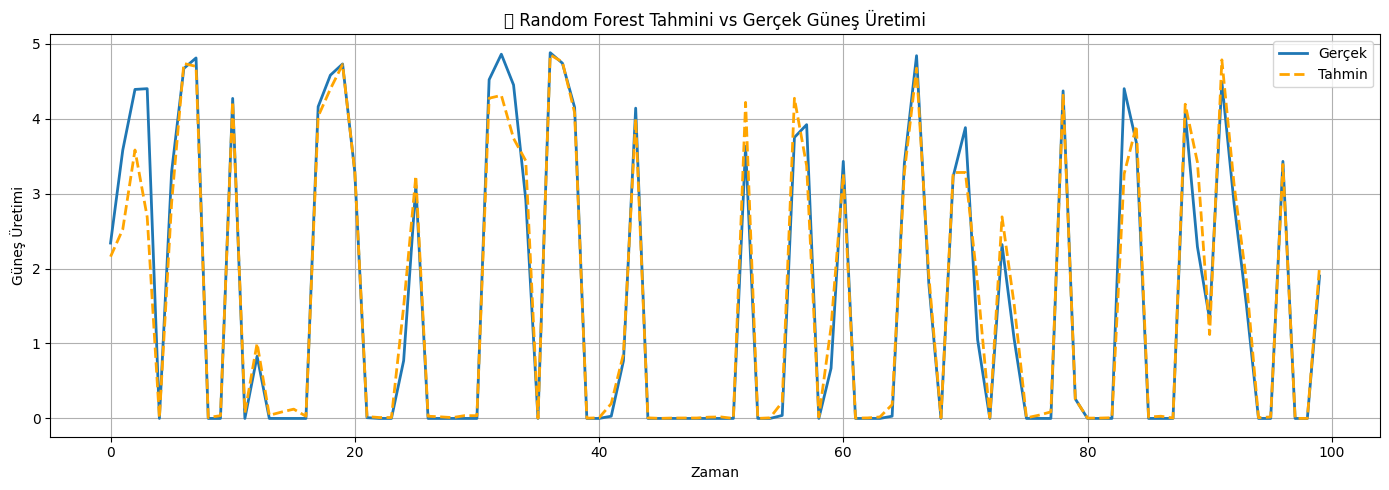

In [ ]:
# **RF Modeli oluştur**
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor
forest = RandomForestRegressor(n_estimators=300)

# **Modeli eğit**
# Reshape X_train and X_test to 2D before fitting the RandomForest model
X_train_2d = X_train.reshape(X_train.shape[0], -1)  # Reshape to (samples, timesteps * features)
X_test_2d = X_test.reshape(X_test.shape[0], -1)  # Reshape to (samples, timesteps * features)
model2 = forest.fit(X_train_2d, y_train)  # Fit with reshaped data

# **Model ile tahmin yap**
y_pred = model2.predict(X_test_2d)  # Predict with reshaped data

# **Performansı değerlendir**
from sklearn.metrics import mean_absolute_error # Import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"📈 Test Seti R² Skoru: {r2:.2f}")

# **Sonucu yazdır**
print(f"\n📊 Test Seti Mean Absolute Error (MAE): {mae:.2f}")

plt.figure(figsize=(14, 5))
plt.plot(y_test[:100].values, label="Gerçek", linewidth=2)
plt.plot(y_pred[:100], label="Tahmin", linestyle="--", linewidth=2, color="orange")
plt.title("🌲 Random Forest Tahmini vs Gerçek Güneş Üretimi")
plt.xlabel("Zaman")
plt.ylabel("Güneş Üretimi")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
start_future = datetime(2025, 5, 10)
end_future = datetime(2025, 5, 10, 23, 59)
future_weather = Hourly(weather_station_id, start_future, end_future).fetch()

# 03:00 - 17:00 saat arası filtrele
future_weather = future_weather[(future_weather.index.hour >= 3) & (future_weather.index.hour <= 17)]
future_weather = future_weather.drop(columns=['snow', 'wdir', 'wpgt', 'tsun'], errors='ignore')
future_weather["hour"] = future_weather.index.hour

#Güneş ışınımı hesabı için gerekli hesaplamaları future_weather DataFrame'ine de uygula
# Güneş sabiti
G_sc = 1367

# Güneş açısı için yaklaşık bir model: Sabah ve akşam G0 düşük, öğlen tepe değerde
def cos_theta(hour):
    return np.maximum(0, np.cos((np.pi / 12) * (hour - 12)))

# Günün yıl içindeki sırası
future_weather["day_of_year"] = future_weather.index.dayofyear # future_weather DataFrame'i için day_of_year hesapla

# ε hesabı
future_weather["epsilon"] = 1 + 0.033 * np.cos((2 * np.pi * future_weather["day_of_year"]) / 365)

# cos(θ) hesabı
future_weather["cos_theta"] = cos_theta(future_weather["hour"])

# G0 hesabı (W/m^2 cinsinden)
future_weather["G0"] = future_weather["epsilon"] * G_sc * future_weather["cos_theta"]


# Normalize et
X_future = scaler.transform(future_weather[features])

# Tahmin yap
future_predictions = model2.predict(X_future)

# Tahminleri dataframe'e ekle
future_weather["predicted_gunes"] = future_predictions

# Sonuçları göster
print("\n🔮 Gelecekteki Güneş Enerjisi Üretimi Tahminleri:")
print(future_weather[["predicted_gunes"]])

In [ ]:
#ANN MODELİ
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"]) # Fixed: Removed unexpected indent

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Eğit
history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                    validation_split=0.2, callbacks=[early_stop], verbose=0)

# Değerlendir
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
mae_scores.append(test_mae)

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"📈 Test Seti R² Skoru: {r2:.2f}")

print(f"\n📊 ANN Ortalama MAE (5-Fold): {np.mean(mae_scores):.2f}")

# Eğer ANN tahminlerini yapmadıysan önce yap:
y_pred = model.predict(X_test).flatten()

# Grafik oluştur
plt.figure(figsize=(14, 5))
plt.plot(y_test[:100].values, label="Gerçek", linewidth=2)
plt.plot(y_pred[:100], label="Tahmin", linestyle="--", linewidth=2, color="orange")
plt.title("🧠 ANN Tahmini vs Gerçek Güneş Üretimi")
plt.xlabel("Zaman")
plt.ylabel("Güneş Üretimi")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
#LİNEER REGRESYON MODELİ
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. Veri bölme ---
X = merged_data[["temp", "rhum", "pres", "prcp", "hour","G0"]]
y = merged_data["gunes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 2. Özellikleri normalize et (Linear Regression için önemli) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 3. Modeli oluştur ve eğit ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# --- 4. Tahmin yap ---
y_pred = lr_model.predict(X_test_scaled)
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
# --- 5. Performans değerlendirmesi ---
mae = mean_absolute_error(y_test, y_pred)
print(f"\n📊 Linear Regression MAE: {mae:.2f}")
print(f"📈 Test Seti R² Skoru: {r2:.2f}")



In [ ]:
# Özellik isimleri ve hedef değişken
weather_features = ["temp", "rhum", "pres", "prcp", "hour", "dwpt", "coco", "wspd", "G0"]
target = "gunes"
hours_per_day = 15  # 03:00–17:00


X shape: (6483, 45, 9)
y shape: (6483, 15)


Epoch 1/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.1840 - val_loss: 0.0939
Epoch 2/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0875 - val_loss: 0.0928
Epoch 3/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0769 - val_loss: 0.0982
Epoch 4/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0753 - val_loss: 0.0877
Epoch 5/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0718 - val_loss: 0.0919
Epoch 6/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0705 - val_loss: 0.0881
Epoch 7/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0686 - val_loss: 0.0836
Epoch 8/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0673 - val_loss: 0.0830
Epoch 9/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0665 - val_loss: 0.0808
Epoch 10/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0634 - val_loss: 0.0783
Epoch 11/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0621 - val_loss: 0.0798
Epoch 12/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 

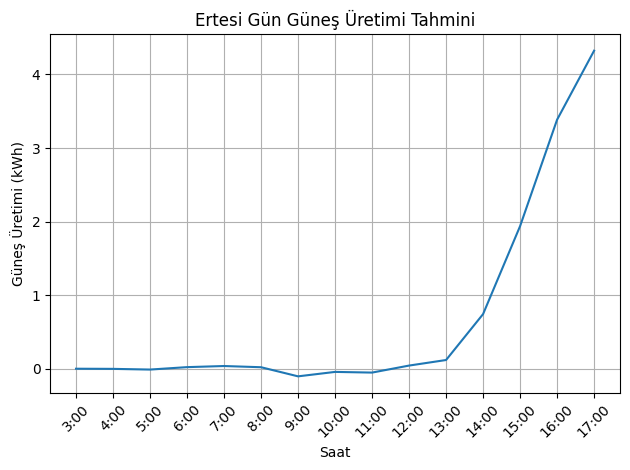

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Özellik ve hedef ayrımı
features = ["temp", "rhum", "pres", "prcp", "hour", "dwpt", "coco", "wspd", "G0"]
target = "gunes"

X = merged_data[features]
y = merged_data[target]

# Normalize
scaler_x = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Zaman serisi veri oluşturma (geçmiş 3 gün = 45 saat ➜ ertesi gün 15 saat tahmin)
look_back = 45
forecast_horizon = 15

X_lstm = []
y_lstm = []

for i in range(len(X_scaled) - look_back - forecast_horizon):
    X_lstm.append(X_scaled[i:i+look_back])
    y_lstm.append(y_scaled[i+look_back:i+look_back+forecast_horizon].flatten())

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

# LSTM modeli
model = Sequential()
model.add(LSTM(units=64, input_shape=(look_back, X_lstm.shape[2]), return_sequences=False))
model.add(Dense(units=forecast_horizon))  # 15 saatlik çıktı
model.compile(optimizer='adam', loss='mae')

# Eğitimi başlat
model.fit(X_lstm, y_lstm, epochs=20, batch_size=32, validation_split=0.1)

# Tahmin (son 3 günlük veriye bakarak)
last_input = X_scaled[-look_back:]
last_input = np.expand_dims(last_input, axis=0)

predicted_scaled = model.predict(last_input)
predicted = scaler_y.inverse_transform(predicted_scaled).flatten()

# Görselleştirme
prediction_hours = [f"{h}:00" for h in range(3, 18)]
plt.plot(prediction_hours, predicted)
plt.title("Ertesi Gün Güneş Üretimi Tahmini")
plt.xlabel("Saat")
plt.ylabel("Güneş Üretimi (kWh)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
